In [16]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from torchcodec.encoders import VideoEncoder
from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../')

In [37]:
import os
from pathlib import Path
from typing import Any, Callable, Optional, Union, cast

import torch
from torchvision.transforms import v2
import numpy as np

%load_ext autoreload
%autoreload 2

from computer_vision.torch_video.data.dataset import UCF101, ConvertTCHWtoCTHW
from computer_vision.torch_video.parameter_parser import parser

DATA_MEAN=(0.43216, 0.394666, 0.37645)
DATA_STD=(0.22803, 0.22145, 0.216989)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
data_dirpath=Path('D:/data/UCF101')
root=data_dirpath/'UCF-101'
annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask'
metadata_path=data_dirpath/'metadata.pt'


arguments= f"""-d {root} -a {annotation_path} -m {metadata_path}
--data-fold 1 --frame-rate 8 --clip-duration 2 --step-duration 1.7 
"""
args=parser.parse_args(arguments.split())


train_dataset=UCF101(root=args.data_path, annotation_path=args.annotation_path, frame_rate=args.frame_rate, 
                     clip_duration=args.clip_duration, step_duration=args.step_duration,
                     train=True, metadata_path=args.metadata_path, fold=args.data_fold, sampling_type='random', use_audio=False,
                     decoder_transforms=[v2.RandomCrop(size=args.train_crop_size),
                                         v2.Resize(args.train_resize_size)],
                     transforms=v2.Compose([
                         v2.RandomHorizontalFlip(p=args.hflip_prob),
                         v2.ToDtype(torch.float32, scale=True),
                         v2.Normalize(mean=DATA_MEAN,std=DATA_STD),
                         ConvertTCHWtoCTHW()])
                    ) 

val_dataset=UCF101(root=args.data_path, annotation_path=args.annotation_path, frame_rate=args.frame_rate, 
                     clip_duration=args.clip_duration, step_duration=args.step_duration,
                     train=False, metadata_path=args.metadata_path, fold=args.data_fold, sampling_type='regular', use_audio=False,
                     decoder_transforms=[v2.CenterCrop(size=args.train_crop_size),
                                         v2.Resize(args.train_resize_size)],
                     transforms=v2.Compose([
                         v2.ToDtype(torch.float32, scale=True),
                         v2.Normalize(mean=DATA_MEAN,std=DATA_STD),
                         ConvertTCHWtoCTHW()])
                    ) 


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.8555756].


video.shape=torch.Size([3, 16, 112, 112]), video.dtype=torch.float32 (-1.895,2.856)
info={'video_fps': 8}, label=0, video_idx=30


(np.float64(-0.5), np.float64(913.5), np.float64(229.5), np.float64(-0.5))

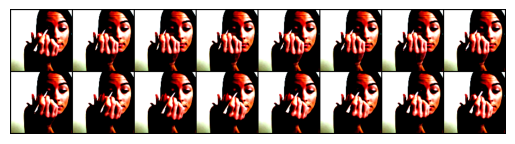

In [48]:
video, label, video_idx, info=train_dataset[100]
print(f"{video.shape=}, {video.dtype=} ({video.min().item():.3f},{video.max().item():.3f})")
print(f"{info=}, {label=}, {video_idx=}")
plt.figure()
plt.imshow(make_grid(video.permute(1,0,2,3)).permute(1,2,0))
plt.axis('off')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8951892..2.729067].


video.shape=torch.Size([3, 16, 112, 112]), video.dtype=torch.float32 (-1.895,2.729)
info={'video_fps': 8}, label=0, video_idx=29


(np.float64(-0.5), np.float64(913.5), np.float64(229.5), np.float64(-0.5))

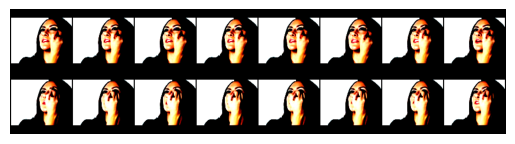

In [49]:
video, label, video_idx, info=val_dataset[100]
print(f"{video.shape=}, {video.dtype=} ({video.min().item():.3f},{video.max().item():.3f})")
print(f"{info=}, {label=}, {video_idx=}")
plt.figure()
plt.imshow(make_grid(video.permute(1,0,2,3)).permute(1,2,0))
plt.axis('off')